# Pipeline qualità italia-corpus — Analisi completa

**Data**: 2026-10-02 · **Repo**: `dataciviclab/italia-corpus`
**Branch**: `feat/quality-pipeline` (PR #45)

## Obiettivo

Capire quanta parte del corpus è "reale" e cosa rivela sulla legislazione italiana.

## Domande

1. Da 22.016 atti, quanti sono realmente vigenti e utili?
2. Come si distribuiscono per qualità, materia, età?
3. Cos'è il sunsetting e quanto peso ha il problema?
4. Qual è la struttura del grafo normativo?
5. Come si dovrebbe strutturare un testo normativo ottimale?

## 1. Setup

In [1]:
import duckdb
import pandas as pd
from pathlib import Path

REPO = Path('..').resolve()
DATA = REPO / 'data' / 'derived'

normativa = duckdb.sql(f"SELECT * FROM read_parquet('{DATA}/normativa.parquet')").df()
riferimenti = duckdb.sql(f"SELECT * FROM read_parquet('{DATA}/riferimenti.parquet')").df()

print(f"normativa: {len(normativa):,} atti, {len(normativa.columns)} colonne")
print(f"riferimenti: {len(riferimenti):,} archi")

normativa: 22,016 atti, 30 colonne
riferimenti: 92,580 archi


## 2. Distribuzione per stato

Il primo dato: quanto del corpus è realmente vigente?

In [2]:
stato_dist = normativa['stato'].value_counts()
print("Distribuzione stato:")
for s, n in stato_dist.items():
    print(f"  {s:10} {n:>6,}  ({100*n/len(normativa):.1f}%)")

print(f"\nVolume per stato (mln parole):")
vol = normativa.groupby('stato')['lunghezza_parole'].sum() / 1e6
print(vol.round(1))

Distribuzione stato:
  vigente    12,901  (58.6%)
  abrogato    7,354  (33.4%)
  decaduto    1,761  (8.0%)

Volume per stato (mln parole):
stato
abrogato     0.5
decaduto     0.3
vigente     61.9
Name: lunghezza_parole, dtype: float64


## 3. La Sieve — da 22k al nucleo reale

Applichiamo filtri progressivi per isolare gli atti che contano.

In [3]:
# Sieve progressiva
steps = []

n_total = len(normativa)
steps.append(('Totale corpus', n_total, 100.0))

# 1. Solo vigenti
df = normativa[normativa['stato'] == 'vigente'].copy()
steps.append(('Solo vigenti', len(df), 100*len(df)/n_total))

# 2. Senza duplicati
df = df[df['duplicato'] == False]
steps.append(('Senza duplicati', len(df), 100*len(df)/n_total))

# 3. Senza orfani morti
df = df[~(df['orfano'] & (df['lunghezza_parole'] < 500))]
steps.append(('Senza orfani morti', len(df), 100*len(df)/n_total))

# 4. Senza candidati sunsetting
df = df[df['sunsetting_score'] <= 50]
steps.append(('Senza sunsetting', len(df), 100*len(df)/n_total))

# 5. Con sostanza
df = df[df['lunghezza_parole'] > 200]
steps.append(('Con sostanza (>200p)', len(df), 100*len(df)/n_total))

# 6. Con citazioni
df_rilevanti = df[df['n_citazioni'] > 0].copy()
steps.append(('Con citazioni', len(df_rilevanti), 100*len(df_rilevanti)/n_total))

# 7. Strutturali
df_pilastri = df[df['n_citazioni'] >= 3].copy()
steps.append(('Strutturali (3+ cit)', len(df_pilastri), 100*len(df_pilastri)/n_total))

print("SIEVE PROGRESSIVA")
print("=" * 55)
for name, n, pct in steps:
    bar = "█" * int(pct / 2)
    print(f"  {name:25} {n:>6,}  {pct:>5.1f}%  {bar}")

print(f"\n{'=' * 55}")
print(f"Nucleo rilevante: {len(df_rilevanti):,} atti = {100*len(df_rilevanti)/n_total:.1f}%")
print(f"Pilastri:         {len(df_pilastri):,} atti = {100*len(df_pilastri)/n_total:.1f}%")

SIEVE PROGRESSIVA
  Totale corpus             22,016  100.0%  ██████████████████████████████████████████████████
  Solo vigenti              12,901   58.6%  █████████████████████████████
  Senza duplicati           10,898   49.5%  ████████████████████████
  Senza orfani morti         8,110   36.8%  ██████████████████
  Senza sunsetting           7,959   36.2%  ██████████████████
  Con sostanza (>200p)       7,385   33.5%  ████████████████
  Con citazioni              2,951   13.4%  ██████
  Strutturali (3+ cit)       1,875    8.5%  ████

Nucleo rilevante: 2,951 atti = 13.4%
Pilastri:         1,875 atti = 8.5%


## 4. Il nucleo rilevante per materia

Gli atti che contano davvero, per tema.

In [4]:
materie = df_rilevanti.groupby('materia').agg(
    n=('filename', 'count'),
    score_medio=('qualita_score', 'mean'),
    citazioni_medie=('n_citazioni', 'mean'),
    parole_medie=('lunghezza_parole', 'mean')
).sort_values('n', ascending=False)

print("Nucleo rilevante per materia:")
print(materie.round(1).to_string())

print(f"\nTop 5 materie = {materie['n'].head(5).sum():,} atti = "
      f"{100*materie['n'].head(5).sum()/len(df_rilevanti):.0f}% del rilevante")

Nucleo rilevante per materia:
                     n  score_medio  citazioni_medie  parole_medie
materia                                                           
fisco              751        100.0             30.9       14284.8
altro              458        100.0             17.4        9438.9
strutturale        219        100.0             20.4        1236.5
lavoro             180        100.0             34.9        9093.5
giustizia          146        100.0             29.0        6222.0
ambientale         126        100.0             15.6        9390.0
enti-locali        123        100.0             24.4        5625.5
cultura            121        100.0             14.0        5194.5
istruzione         121        100.0             13.7        7063.5
affari-esteri      102        100.0              5.0        3486.7
sanita             101        100.0             11.2        5688.5
trasporti           94        100.0             18.6        4797.4
difesa              78        10

## 5. Quality Score — distribuzione

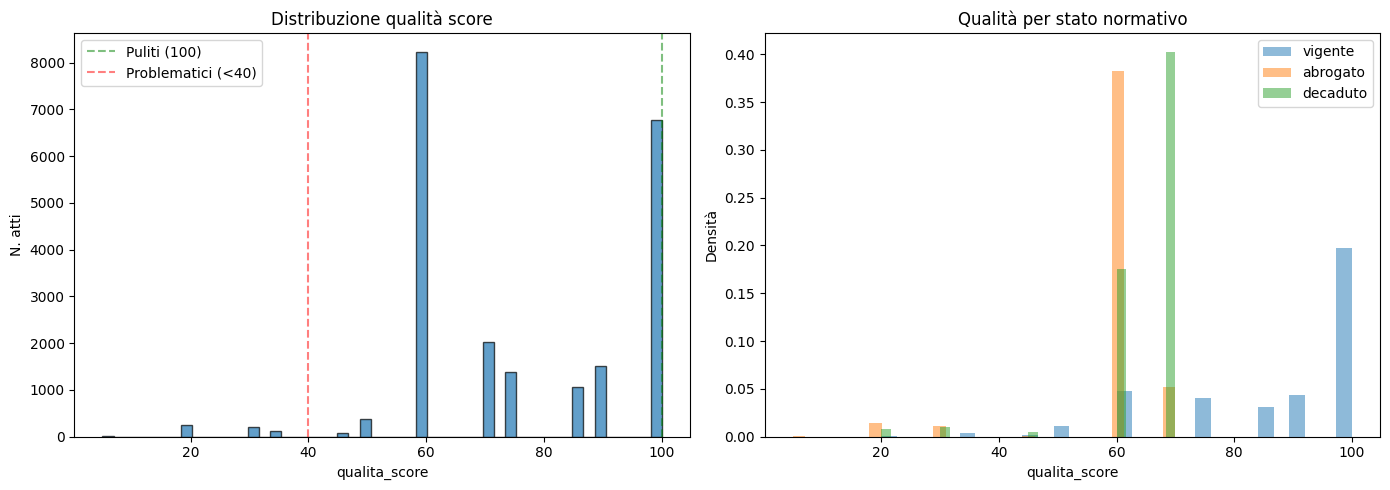

Statistiche qualità:
            count  mean   std   min   25%    50%    75%    max
stato                                                         
abrogato   7354.0  59.1   9.2   5.0  60.0   60.0   60.0   70.0
decaduto   1761.0  65.6   8.6  20.0  60.0   70.0   70.0   70.0
vigente   12901.0  87.6  16.4  20.0  75.0  100.0  100.0  100.0


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(normativa['qualita_score'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('qualita_score')
axes[0].set_ylabel('N. atti')
axes[0].set_title('Distribuzione qualità score')
axes[0].axvline(x=100, color='green', linestyle='--', alpha=0.5, label='Puliti (100)')
axes[0].axvline(x=40, color='red', linestyle='--', alpha=0.5, label='Problematici (<40)')
axes[0].legend()

# Score by stato
for stato in ['vigente', 'abrogato', 'decaduto']:
    data = normativa[normativa['stato'] == stato]['qualita_score']
    axes[1].hist(data, bins=30, alpha=0.5, label=stato, density=True)
axes[1].set_xlabel('qualita_score')
axes[1].set_ylabel('Densità')
axes[1].set_title('Qualità per stato normativo')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statistiche qualità:")
print(normativa.groupby('stato')['qualita_score'].describe().round(1))

## 6. Sunsetting — il sistema non si pulisce

Il ratio produzione/abrogazione è il dato più eloquente.

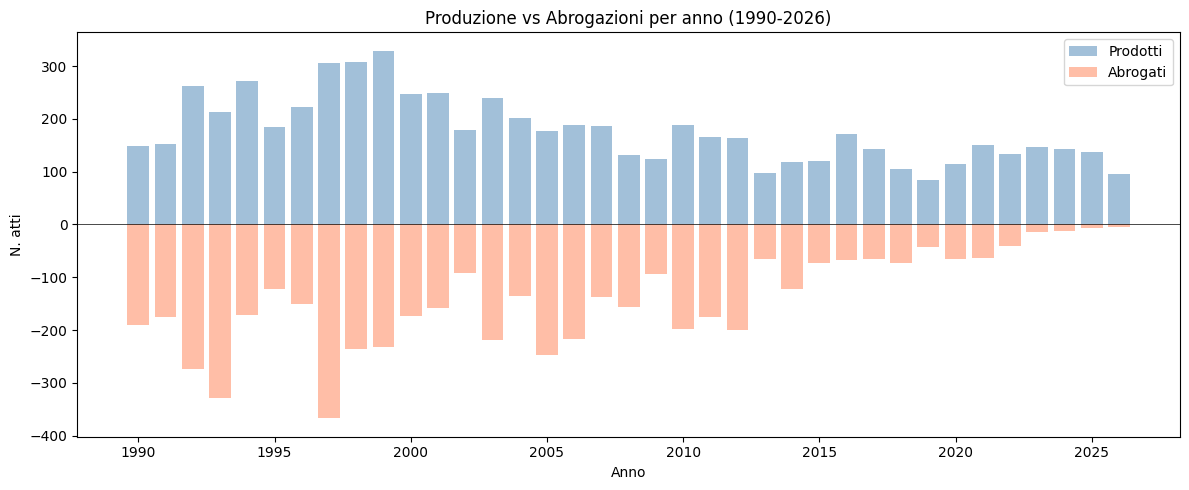

Ratio abrogazioni/produzione:
 anno_atto  prodotti  abrogati  ratio
      2017       143      65.0   0.45
      2018       105      72.0   0.69
      2019        85      42.0   0.49
      2020       115      65.0   0.57
      2021       150      63.0   0.42
      2022       134      40.0   0.30
      2023       146      15.0   0.10
      2024       143      13.0   0.09
      2025       138       7.0   0.05
      2026        95       4.0   0.04

Ratio 1990: 1.28
Ratio 2026: 0.04


In [6]:
# Ratio produzione/abrogazione per anno
produzione = (normativa[normativa['filename'].str.contains('ORIGINALE')]
              .groupby('anno_atto').size().reset_index(name='prodotti'))

abrogazioni = duckdb.sql(f"""
    SELECT abrogated_year AS anno_atto, COUNT(*) AS abrogati
    FROM read_parquet('{DATA}/abrogations_raw.parquet')
    WHERE abrogated_year >= 1990
    GROUP BY 1
""").df()

df_ratio = produzione.merge(abrogazioni, on='anno_atto', how='outer').fillna(0)
df_ratio = df_ratio[df_ratio['anno_atto'] >= 1990].sort_values('anno_atto')
df_ratio['ratio'] = df_ratio['abrogati'] / df_ratio['prodotti'].replace(0, 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_ratio['anno_atto'], df_ratio['prodotti'], alpha=0.5, label='Prodotti', color='steelblue')
ax.bar(df_ratio['anno_atto'], -df_ratio['abrogati'], alpha=0.5, label='Abrogati', color='coral')
ax.set_xlabel('Anno')
ax.set_ylabel('N. atti')
ax.set_title('Produzione vs Abrogazioni per anno (1990-2026)')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Ratio abrogazioni/produzione:")
print(df_ratio[['anno_atto', 'prodotti', 'abrogati', 'ratio']].tail(10).round(2).to_string(index=False))
print(f"\nRatio 1990: {df_ratio.iloc[0]['ratio']:.2f}")
print(f"Ratio 2026: {df_ratio.iloc[-1]['ratio']:.2f}")

## 7. Candidati Sunsetting

In [7]:
print("Sunsetting score distribution:")
bins = [0, 20, 40, 50, 70, 100]
labels = ['0-20', '20-40', '40-50', '50-70', '70-100']
normativa['sunset_bucket'] = pd.cut(normativa['sunsetting_score'], bins=bins, labels=labels)
print(normativa['sunset_bucket'].value_counts().sort_index())

print("\nTop candidati sunsetting (score > 70):")
top_sunset = normativa[normativa['sunsetting_score'] > 70][
    ['filename', 'materia', 'anno_atto', 'n_citazioni', 'sunsetting_score', 'oggetto']
].sort_values('sunsetting_score', ascending=False).head(10)
print(top_sunset.to_string(index=False))

print("\nDL proroghe con >20 anni:")
proroghe = normativa[
    (normativa['collezione'].str.contains('DL proroghe')) & 
    (normativa['stato'] == 'vigente') &
    ((2026 - normativa['anno_atto']) > 20)
][['filename', 'anno_atto', 'oggetto']]
proroghe['eta'] = 2026 - proroghe['anno_atto']
print(proroghe.sort_values('eta', ascending=False).to_string(index=False))

Sunsetting score distribution:
sunset_bucket
0-20      3349
20-40     3721
40-50      163
50-70     7487
70-100       8
Name: count, dtype: int64

Top candidati sunsetting (score > 70):
                                    filename       materia  anno_atto  n_citazioni  sunsetting_score                                                                                                                                                                                                                                                 oggetto
1979-09-25_079U0467_VIGENZA_2025-06-12_V0.md    ambientale       1979            0                95                                                                                                     Proroga di termini ed integrazione delle leggi 16 aprile 1973, n. 171 e 10 maggio 1976, n. 319, in materia di tutela delle acque dall'inquinamento.
1984-12-31_084U0903_VIGENZA_2025-06-12_V0.md     trasporti       1984            0                75                

## 8. Grafo normativo — topologia

Chi è collegato a chi, e con quale peso.

In [8]:
print("Top 10 hub (più citati):")
hub = normativa.nlargest(10, 'n_citazioni')[
    ['filename', 'tipo', 'anno_atto', 'materia', 'n_citazioni', 'qualita_score']
]
print(hub.to_string(index=False))

print("\nDistribuzione in-degree:")
indeg = normativa['n_citazioni']
buckets = pd.cut(indeg, bins=[0, 1, 5, 20, 100, float('inf')], \
                 labels=['0', '1-5', '6-20', '21-100', '100+'])
print(buckets.value_counts().sort_index())

print("\nTop coppie cross-materia:")
cross = riferimenti[
    (riferimenti['risolto']) & 
    (riferimenti['fonte_materia'] != '') & 
    (riferimenti['bersaglio_materia'] != '') &
    (riferimenti['fonte_materia'] != riferimenti['bersaglio_materia'])
].groupby(['fonte_materia', 'bersaglio_materia']).size().reset_index(name='n')
print(cross.nlargest(10, 'n').to_string(index=False))

Top 10 hub (più citati):
                                    filename                                    tipo  anno_atto     materia  n_citazioni  qualita_score
         1986-05-29_085U1092_ORIGINALE_V0.md DECRETO DEL PRESIDENTE DELLA REPUBBLICA       1985       altro         6755            100
         1997-03-17_097G0099_ORIGINALE_V0.md                                   LEGGE       1997       fisco         1696            100
         1930-10-26_030U1398_ORIGINALE_V0.md                           REGIO DECRETO       1930   giustizia         1434            100
         1993-02-06_093G0067_ORIGINALE_V0.md                     DECRETO LEGISLATIVO       1993      lavoro         1091            100
2013-01-04_13G00003_VIGENZA_2026-02-18_V0.md                                   LEGGE       2012       fisco         1002            100
         2001-05-09_001G0219_ORIGINALE_V0.md                     DECRETO LEGISLATIVO       2001      lavoro          890            100
1946-03-23_046U0098_VIG

## 9. Citazioni costituzionali

Quali articoli della Costituzione guidano la legislazione.

In [9]:
print("Atti con citazioni costituzionali:")
con_cost = normativa[normativa['n_articoli_cost'] > 0]
print(f"  {len(con_cost):,} atti su {len(normativa):,} ({100*len(con_cost)/len(normativa):.1f}%)")

print("\nArticoli costituzionali più citati (negli atti vigenti):")
art_counts = {}
for arts in con_cost[con_cost['stato'] == 'vigente']['articoli_cost']:
    for a in str(arts).split(','):
        a = a.strip()
        if a:
            art_counts[a] = art_counts.get(a, 0) + 1

top_arts = sorted(art_counts.items(), key=lambda x: -x[1])[:10]
for art, n in top_arts:
    print(f"  Art. {art:>3}: {n:>5} atti")

Atti con citazioni costituzionali:
  3,702 atti su 22,016 (16.8%)

Articoli costituzionali più citati (negli atti vigenti):
  Art.  87:  3184 atti
  Art.  76:  2232 atti
  Art. 117:   519 atti
  Art. 118:   125 atti
  Art.  33:    99 atti
  Art.  97:    89 atti
  Art. 119:    77 atti
  Art. 120:    73 atti
  Art.  77:    71 atti
  Art.  86:    69 atti


## 10. Materia × Stato — heatmap

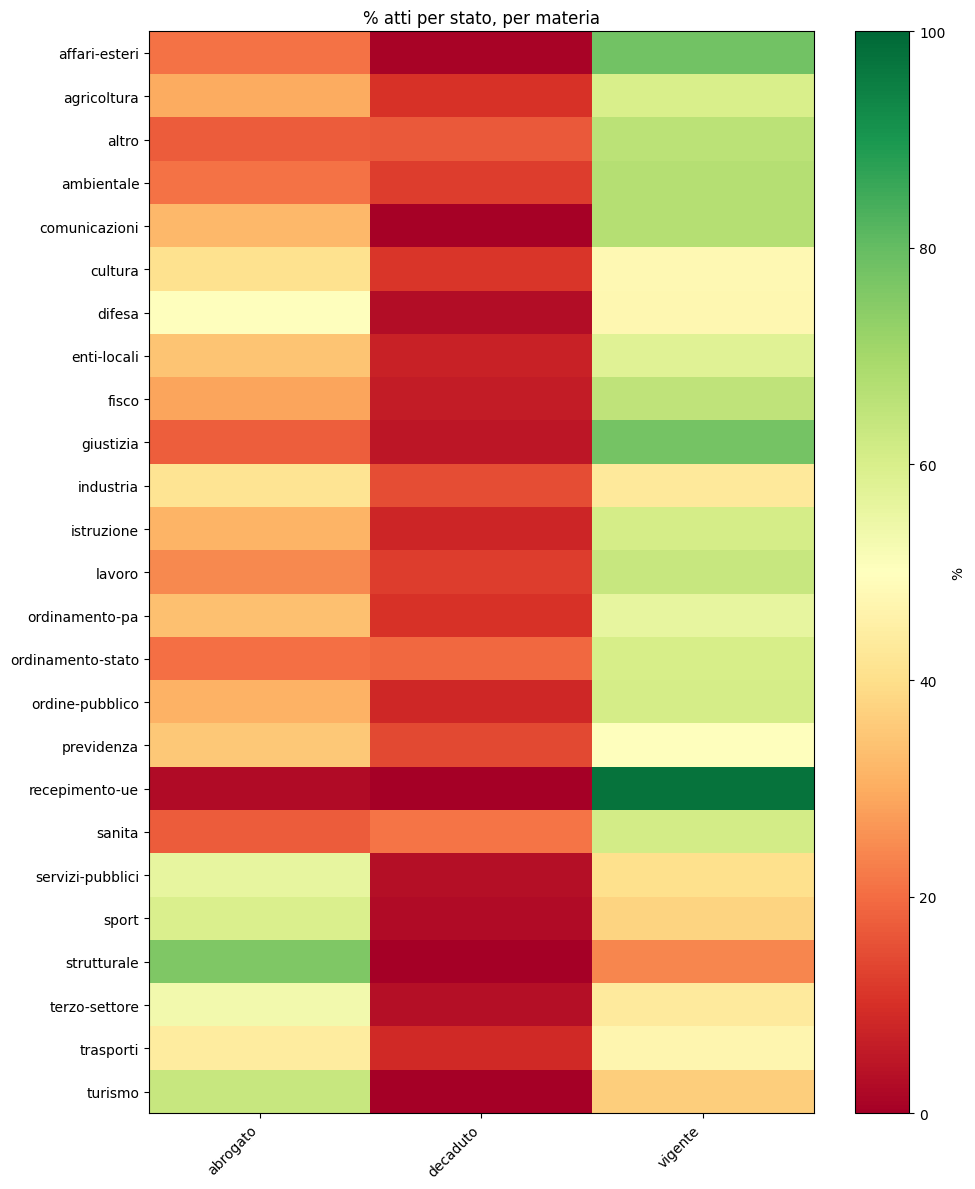

% vigenti per materia:
materia
recepimento-ue       97.5
affari-esteri        77.9
giustizia            77.5
ambientale           67.0
comunicazioni        66.9
altro                65.9
fisco                65.1
lavoro               63.4
sanita               61.1
ordine-pubblico      60.8
istruzione           60.6
ordinamento-stato    60.2
agricoltura          59.9
enti-locali          58.1
ordinamento-pa       56.0
previdenza           50.3
cultura              48.0
difesa               47.3
trasporti            47.3
terzo-settore        43.5
industria            43.3
servizi-pubblici     40.4
sport                37.7
turismo              36.4
strutturale          24.1


In [10]:
ct = pd.crosstab(normativa['materia'], normativa['stato'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 12))
im = ax.imshow(ct.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index)
ax.set_title('% atti per stato, per materia')
plt.colorbar(im, ax=ax, label='%')
plt.tight_layout()
plt.show()

print("% vigenti per materia:")
vig_pct = (normativa[normativa['stato'] == 'vigente']['materia'].value_counts() / 
           normativa['materia'].value_counts() * 100).sort_values(ascending=False)
print(vig_pct.round(1).to_string())

## 11. Sintesi

### Cosa emerge

1. **Il 41% del corpus non è vigente** (abrogati + decaduti tombstone)
2. **Solo il 13% è realmente rilevante** (vigenti, citati, di qualità)
3. **Il sistema non si pulisce**: ratio produzione/abrogazione da 1,28 (1990) a 0,04 (2026)
4. **7.495 candidati sunsetting** — atti vigenti che nessuno cita da anni
5. **Il fisco è il ponte** che collega tutte le materie
6. **Art. 76 + 87 dominano** — il sistema è fondato sulla delega

### Lo standard per un testo ottimale

| Dimensione | Target |
|---|---|
| Lunghezza | 500 – 15.000 parole |
| Rinvii in uscita | ≤ 30 |
| Materie per atto | 1 |
| Gulpease | ≥ 45 |
| Frasi | ≤ 25 parole |
| Sunsetting | Revisione ogni 5-10 anni |
